# pymesh2D: Mesh Generation for Cádiz - GreenSurge Application

[![GitHub](https://img.shields.io/badge/GitHub-pymesh2d-blue?logo=github)](https://github.com/GeoOcean/pymesh2d)

This notebook demonstrates how to use **pymesh2D** to generate unstructured triangular meshes for hydrodynamic modeling of Cádiz island. 
The workflow creates a nested mesh system with:
- A **forcing grid** (coarse mesh for wind/pressure forcing)
- A **computational grid** (refined mesh for detailed hydrodynamics)

The output is configured to be used in **GreenSurge2.0** (hybrid storm surge model) and **Delft3D FM**.

---

## Table of Contents

1. [Data Loading](#1-loading-bathymetric-data)
2. [Domain Extraction](#2-domain-extraction-from-bathymetry)
3. [Forcing Grid Generation](#3-forcing-grid-generation)
4. [Computational Domain Preparation](#4-computational-domain-preparation)
5. [Edge Intersection Processing](#5-edge-intersection-with-computational-domain)
6. [Computational Grid Generation](#6-computational-grid-generation)
7. [Mesh Quality Control](#7-mesh-quality-control)
8. [GreenSurge Configuration Export](#8-greensurge-configuration-export)
9. [Grid Export for Delft3D FM](#9-grid-export-for-delft3d-fm)
10. [Boundary Conditions Setup](#10-boundary-conditions-setup)

---

## 1. Loading Bathymetric Data

We start by loading bathymetric data from a GeoTIFF raster file containing elevation data for cadiz.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pyproj
from pymesh2d.geom_util.getiso import getiso_polygone
from pymesh2d.geom_util.poly_util import (
    buffer_area,
    polygon_to_node_edge,
    resample_polygon_iterate,
)
from pymesh2d.geom_util.proj_util import (
    get_utm_crs_from_crs,
    reproject_geometry,
    reproject_node,
)
from pymesh2d.geomesh_util.border_util import clean_polygon
from pymesh2d.refine import refine
from pymesh2d.smood import smood
from pymesh2d.smooth import smooth
from shapely.geometry import Point

In [2]:
code = 4326
crs = pyproj.CRS.from_epsg(code)
crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [3]:
import xarray as xr

lon = -6.275007819689623
lat = 36.561314888432776

PP = Point(lon, lat).buffer(0.001)
Aera_UTM = reproject_geometry(PP, crs, get_utm_crs_from_crs(crs)).buffer(50000)
Aera = reproject_geometry(Aera_UTM, get_utm_crs_from_crs(crs), crs)

minx, miny, maxx, maxy = Aera.bounds

bbox = {
    "lon_min": minx,
    "lon_max": maxx,
    "lat_min": miny,
    "lat_max": maxy,
}

emodnet = xr.open_dataset(
    "https://geoocean.unican.es/thredds/dodsC/geoocean/emodnet-bathy-2024",
    engine="netcdf4",
)

# Extract the region of interest
emodnet_sel = emodnet.sel(
    lon=slice(bbox["lon_min"], bbox["lon_max"]),
    lat=slice(bbox["lat_min"], bbox["lat_max"]),
)
emodnet_sel

<xarray.Dataset> Size: 4MB
Dimensions:    (lat: 858, lon: 1065)
Coordinates:
  * lat        (lat) float64 7kB 36.12 36.12 36.12 36.12 ... 37.01 37.01 37.01
  * lon        (lon) float64 9kB -6.829 -6.828 -6.827 ... -5.722 -5.721 -5.72
Data variables:
    elevation  (lat, lon) float32 4MB ...

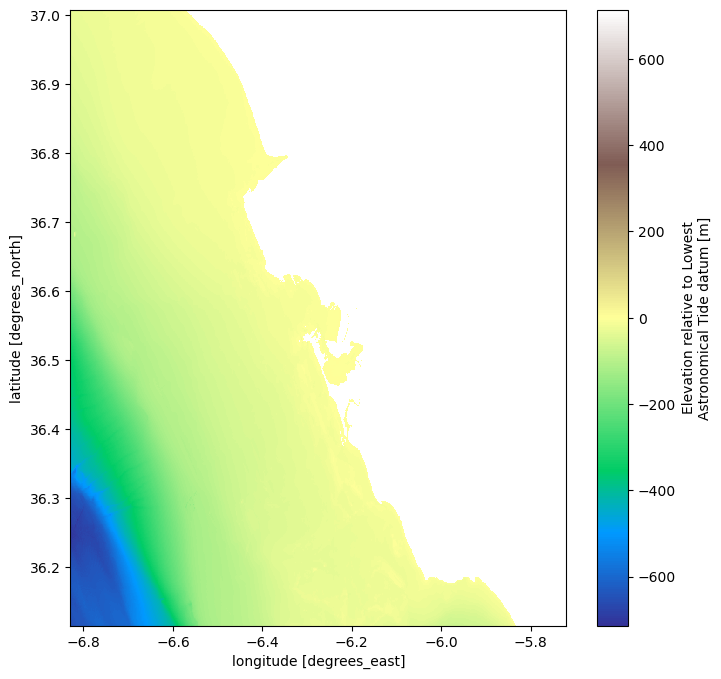

In [4]:
emodnet_sel["elevation"].plot(cmap="terrain", figsize=(8, 8));

In [5]:
lon = emodnet_sel["lon"]
lat = emodnet_sel["lat"]

zdat = emodnet_sel["elevation"]
zdat = zdat.where(~np.isnan(zdat), 20)

---

## 2. Domain Extraction from Bathymetry

Extract three key polygons from the bathymetry:
- **Coastline polygon**: Ocean area (elevation <= 0)
- **Indefinite depth polygon**: Areas with depth > 300m (excluded from computation)
- **Domain polygon**: Full extent of the data

The forcing domain is the intersection of coastline and indefinite depth polygons.

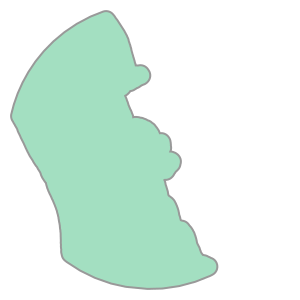

In [6]:
# Extract coastline (ocean area)
polygone_cost = getiso_polygone(lon, lat, zdat, zmax=0.0)

# Extract indefinite depth region (depth > 300m)
polygone_indef = getiso_polygone(lon, lat, -zdat, zmax=150)

# Extract full domain
domain = getiso_polygone(lon, lat, zdat, zmax=np.max(zdat) + 1)

# Reproject to UTM for metric calculations
polygone_cost_UTM = reproject_geometry(polygone_cost, crs, get_utm_crs_from_crs(crs))
polygone_indef_UTM = reproject_geometry(polygone_indef, crs, get_utm_crs_from_crs(crs))
domain_UTM = reproject_geometry(Aera, crs, get_utm_crs_from_crs(crs))
polygone_indef_UTM = polygone_indef_UTM.intersection(domain_UTM)


# Create forcing domain (intersection with area buffer)
Poly_aera_UTM = buffer_area(polygone_cost_UTM.intersection(polygone_indef_UTM), 0.4)
Poly_aera_UTM

---

## 3. Forcing Grid Generation

Generate a coarse mesh (forcing grid) for applying meteorological forcing. 
The polygon is resampled to have vertices every 20 km, creating a sparse mesh for wind/pressure forcing.

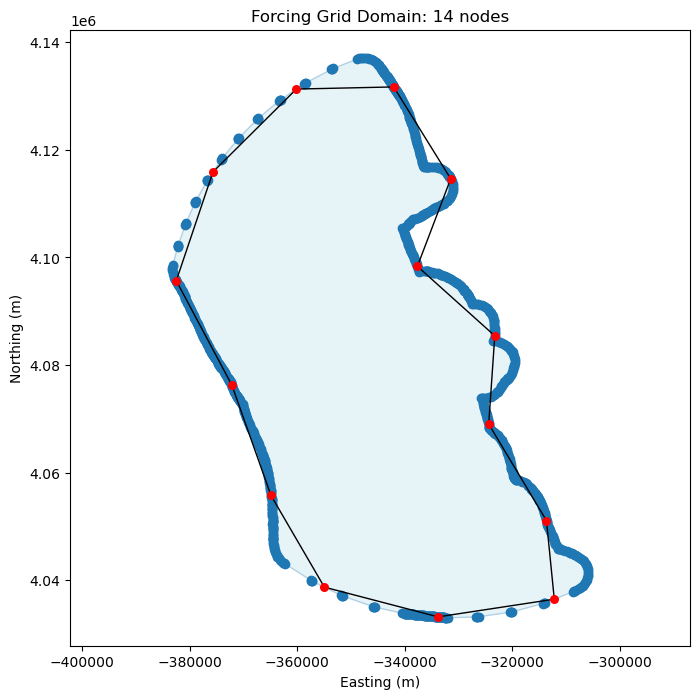

In [7]:
from shapely.plotting import plot_polygon

forcing_tiles_size = 20 * 1000

# Resample polygon with 20 km spacing
Poly_wind_UTM = resample_polygon_iterate(Poly_aera_UTM, forcing_tiles_size)

# Convert to nodes and edges
node, edge = polygon_to_node_edge(Poly_wind_UTM)

# Visualize
fig, ax = plt.subplots(figsize=(8, 8))
plot_polygon(Poly_aera_UTM, ax=ax, facecolor="lightblue", alpha=0.3)
for e in edge.astype(int):
    ax.plot(node[e, 0], node[e, 1], "k-", lw=1)
ax.scatter(node[:, 0], node[:, 1], color="red", s=30, zorder=5)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"Forcing Grid Domain: {len(node)} nodes")
ax.axis("equal");


 Refine triangulation...

 -------------------------------------------------------
      |ITER.|          |CDT1(X)|          |CDT2(X)|     
 -------------------------------------------------------
          1                 14                 12
          4                 14                 24



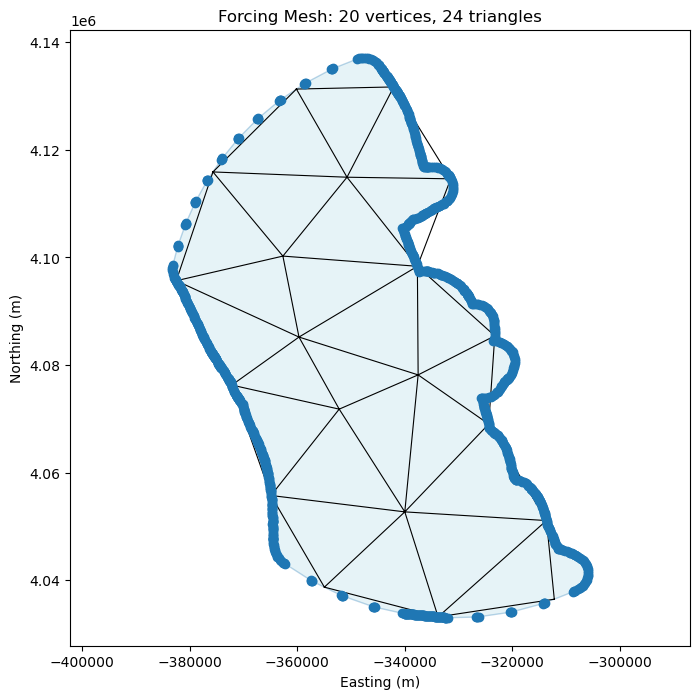

In [8]:
# Generate forcing mesh with Delaunay refinement
vert, etri, tria, tnum = refine(node, edge, [], {}, forcing_tiles_size)

# Visualize
fig, ax = plt.subplots(figsize=(8, 8))
plot_polygon(Poly_aera_UTM, ax=ax, facecolor="lightblue", alpha=0.3)
ax.triplot(vert[:, 0], vert[:, 1], tria[:, 0:3], color="k", lw=0.8)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"Forcing Mesh: {len(vert)} vertices, {len(tria)} triangles")
ax.axis("equal");

---

## 4. Computational Domain Preparation

Prepare the computational domain with finer resolution:
- Resample indefinite depth polygon at 10 km spacing
- Resample coastline polygon at 500 m spacing (for accurate coastal representation)
- Clean small polygons (islands with < 15 vertices)

In [9]:
from pymesh2d.geomesh_util.depth_field import depth_field_from_xr


def hfun_depth_quadratic(test, depth_field, hmin=np.inf, hmax=0):
    """Mesh sizing function based on water depth.

    Element size increases quadratically with depth:
    hfun = 0.14 * h^2 + 28 * h + 655

    Parameters
    ----------
    test : array
        Test point coordinates (N x 2)
    depth_field : callable or array
        Depth values or interpolation function
    hmin : float
        Minimum element size
    """
    if callable(depth_field):
        h = depth_field(test)
    else:
        h = np.asarray(depth_field)
        if h.size == 1:
            h = np.full(test.shape[0], h)

    hfun = np.abs(0.14 * h**2 + 28 * h + 655)
    hfun = np.maximum(hfun, hmin)
    hfun = np.minimum(
        hfun, hmax
    )  # Optional: cap maximum element size for very deep areas

    return hfun


# Create depth field interpolator
depth_field = depth_field_from_xr(
    emodnet_sel,
    input_crs=crs,
    output_crs=get_utm_crs_from_crs(crs),
    var_name="elevation",
)


def hfun(test):
    return hfun_depth_quadratic(test, depth_field, hmin=500, hmax=5000)

In [10]:
from pymesh2d.geom_util.poly_util import resample_polygon_hfun

poly = polygone_cost_UTM.intersection(domain_UTM)

poly_comput_UTM = resample_polygon_hfun(poly, hfun)

# Clean small polygons
poly_comput_UTM_clean = clean_polygon(poly_comput_UTM, min_vertices=15)

# Convert to nodes and edges
node_c, edge_c = polygon_to_node_edge(poly_comput_UTM_clean)

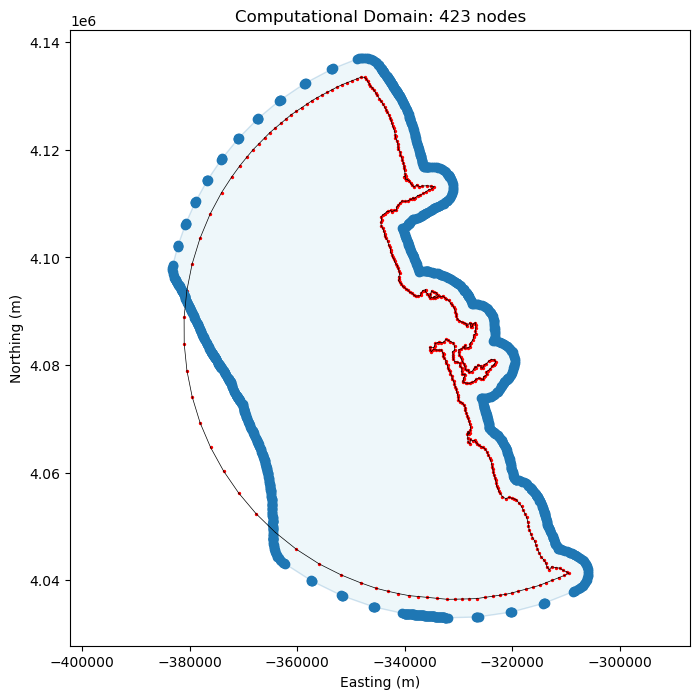

In [11]:
# Visualize computational domain
fig, ax = plt.subplots(figsize=(8, 8))
plot_polygon(Poly_aera_UTM, ax=ax, facecolor="lightblue", alpha=0.2)

for e in edge_c.astype(int):
    ax.plot(node_c[e, 0], node_c[e, 1], "k-", lw=0.5)
ax.scatter(node_c[:, 0], node_c[:, 1], color="red", s=2)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"Computational Domain: {len(node_c)} nodes")
ax.axis("equal");

---

## 5. Edge Intersection with Computational Domain

The forcing mesh edges need to be intersected with the computational domain boundary.
This creates the link between the two mesh levels:
- Edges fully inside the computational domain are kept
- Edges crossing the boundary are clipped at the intersection point

In [12]:
from bluemath_tk.additive.greensurge import add_forcing_edges_to_computational_domain

vert_clean, edges_clean = add_forcing_edges_to_computational_domain(
    buffer_area(poly_comput_UTM_clean, -0.2), vert, tria
)

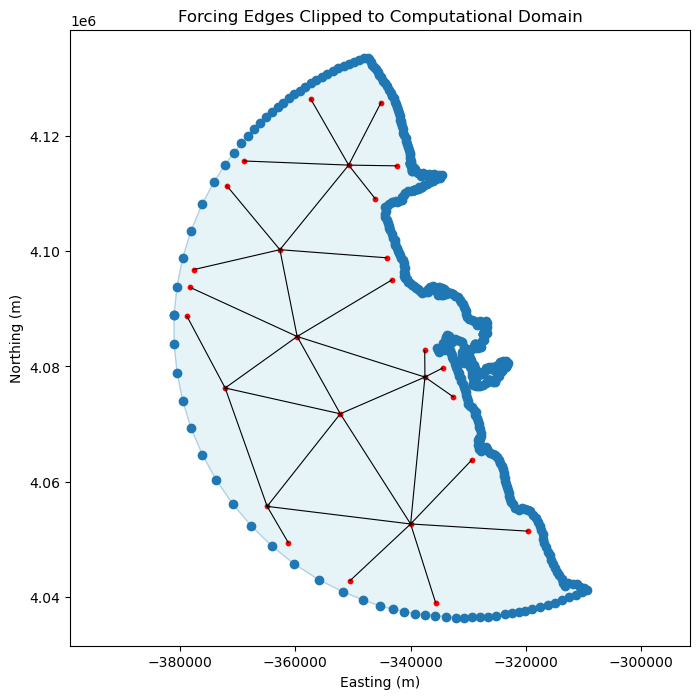

In [13]:
# Visualize clipped forcing edges inside computational domain
fig, ax = plt.subplots(figsize=(8, 8))
plot_polygon(poly_comput_UTM, ax=ax, facecolor="lightblue", alpha=0.3)

for e in edges_clean.astype(int):
    ax.plot(vert_clean[e, 0], vert_clean[e, 1], "k-", lw=0.8)
ax.scatter(vert_clean[:, 0], vert_clean[:, 1], color="red", s=10)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Forcing Edges Clipped to Computational Domain")
ax.axis("equal");

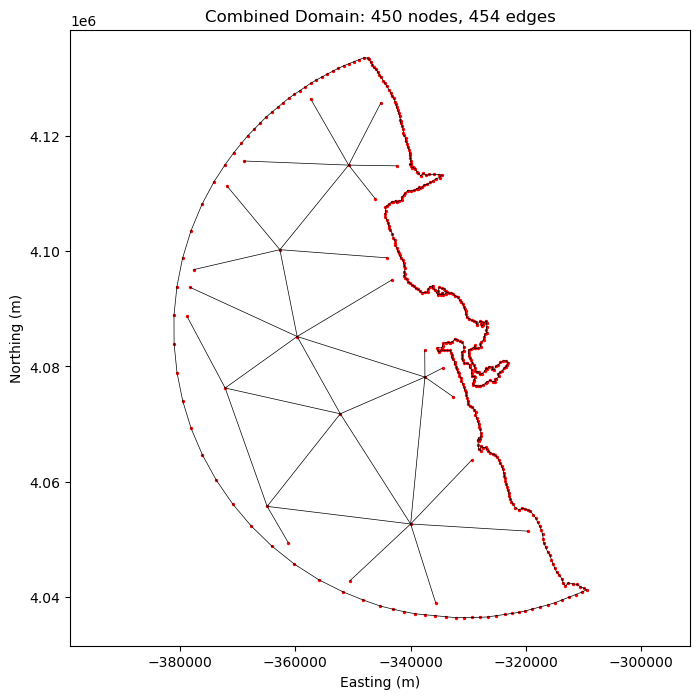

In [14]:
# Combine computational domain boundary with internal forcing edges
part = [np.arange(edge_c.shape[0])]

node_update = np.vstack([node_c, vert_clean])
edge_update = np.vstack([edge_c, edges_clean + len(node_c)])

# Visualize combined edges
fig, ax = plt.subplots(figsize=(8, 8))
for e in edge_update.astype(int):
    ax.plot(node_update[e, 0], node_update[e, 1], "k-", lw=0.5)
ax.scatter(node_update[:, 0], node_update[:, 1], color="red", s=2)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title(f"Combined Domain: {len(node_update)} nodes, {len(edge_update)} edges")
ax.axis("equal");

---

## 6. Computational Grid Generation

Generate the refined computational mesh using a **depth-dependent sizing function**.
The mesh element size varies quadratically with depth to ensure adequate resolution in shallow coastal areas.

In [15]:
# Mesh generation options
opts_refine = {"kind": "delaunay"}
opts_smooth = {}
opts_smood = {"smalllink_threshold": 0.11, "allow_constraint_sliding_junctions": True}

# Generate and smooth computational mesh
vert_c, etri_c, tria_c, tnum_c = refine(
    node_update, edge_update, part, opts_refine, hfun
)
vert_c, etri_c, tria_c, tnum_c = smooth(
    vert_c, etri_c, tria_c, tnum_c, opts_smooth, hfun
)
vert_c, etri_c, tria_c, tnum_c = smood(vert_c, etri_c, tria_c, tnum_c, opts_smood, hfun)


 Refine triangulation...

 -------------------------------------------------------
      |ITER.|          |CDT1(X)|          |CDT2(X)|     
 -------------------------------------------------------
          5                683                475
         10                702               1961
         18                710               4100


 Smooth triangulation...

 -------------------------------------------------------
      |ITER.|          |MOVE(X)|          |DTRI(X)|     
 -------------------------------------------------------
          0               1492               3990
          4               1202               3782
          8                692               3782
         12                390               3790
         16                340               3796
         20                306               3780
         24                170               3780
         28                157               3784


 Smooth triangulation for Delft3D-FM computation...

---

## 7. Mesh Quality Control

### Circumcenter Distance Control for Delft3D FM

For numerical models like **Delft3D FM**, it is essential to control the distance between circumcenters of adjacent triangles.
Small flow links (circumcenters too close together) can cause numerical instabilities in hydrodynamic computations.

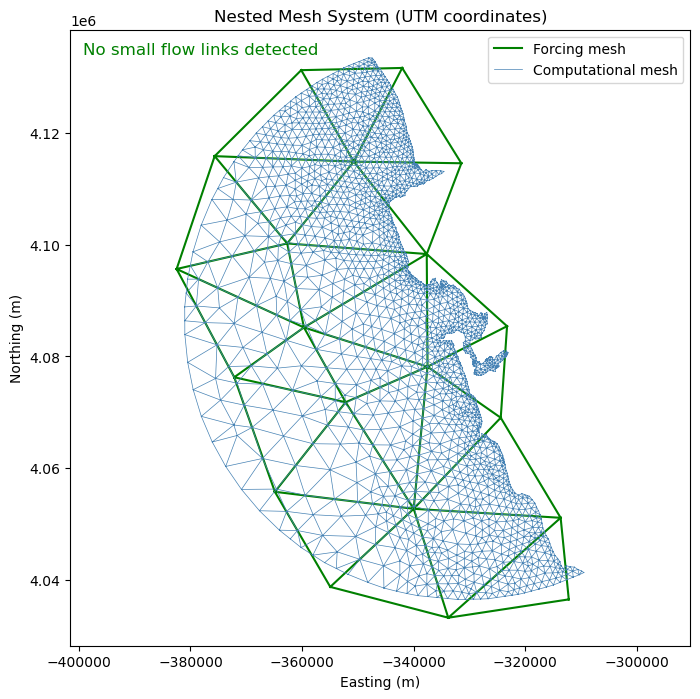

In [16]:
from pymesh2d.mesh_util.circo import small_flow_centers
from pymesh2d.mesh_util.tricon import tricon

# Compute triangle connectivity and identify small flow links
edge_cc, _ = tricon(tria_c, None)

circumcenters, nlinktoosmall = small_flow_centers(
    vert_c, tria_c, edge_cc, removesmalllinkstrsh=0.11, conn=None
)

# Visualize both meshes
fig, ax = plt.subplots(figsize=(8, 8))

ax.triplot(
    vert[:, 0], vert[:, 1], tria[:, 0:3], color="green", lw=1.5, label="Forcing mesh"
)
ax.triplot(
    vert_c[:, 0],
    vert_c[:, 1],
    tria_c[:, 0:3],
    color="steelblue",
    lw=0.5,
    label="Computational mesh",
)

if nlinktoosmall > 0:
    ax.scatter(
        circumcenters[:, 0],
        circumcenters[:, 1],
        color="red",
        s=20,
        alpha=0.7,
        zorder=5,
        label=f"Small flow links ({nlinktoosmall})",
    )
else:
    ax.text(
        0.02,
        0.98,
        "No small flow links detected",
        transform=ax.transAxes,
        fontsize=12,
        color="green",
        verticalalignment="top",
    )

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Nested Mesh System (UTM coordinates)")
ax.legend()
ax.axis("equal");

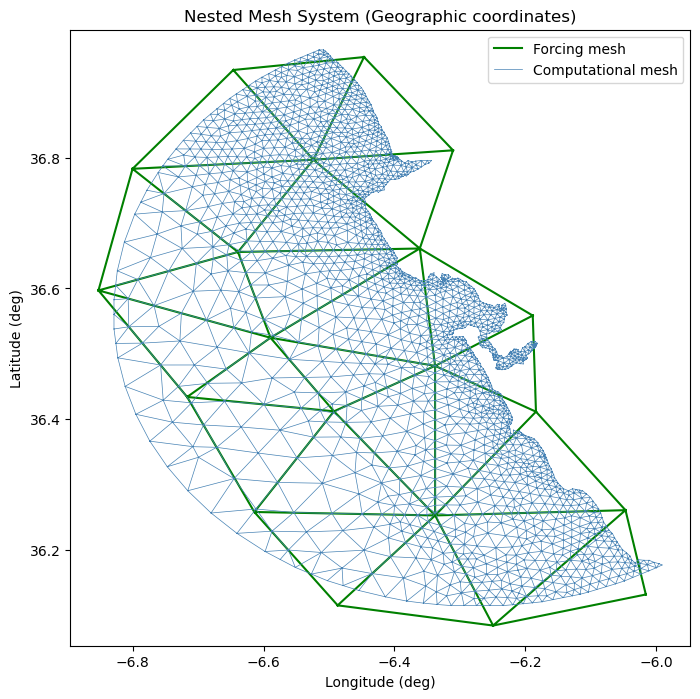

In [17]:
# Reproject to geographic coordinates
vert_geo = reproject_node(vert, get_utm_crs_from_crs(crs), crs)
vert_c_geo = reproject_node(vert_c, get_utm_crs_from_crs(crs), crs)

# Visualize in geographic coordinates
fig, ax = plt.subplots(figsize=(8, 8))

ax.triplot(
    vert_geo[:, 0],
    vert_geo[:, 1],
    tria[:, 0:3],
    color="green",
    lw=1.5,
    label="Forcing mesh",
)
ax.triplot(
    vert_c_geo[:, 0],
    vert_c_geo[:, 1],
    tria_c[:, 0:3],
    color="steelblue",
    lw=0.5,
    label="Computational mesh",
)

ax.set_xlabel("Longitude (deg)")
ax.set_ylabel("Latitude (deg)")
ax.set_title("Nested Mesh System (Geographic coordinates)")
ax.legend()
ax.axis("equal");

---

## 8. GreenSurge Configuration Export

Export the mesh configuration for **GreenSurge**, a hybrid storm surge model.
The dataset includes:
- Computational and forcing grid geometries
- Discretized wind directions
- Simulation parameters (duration, time step, friction coefficients)

In [18]:
from datetime import datetime

# Simulation parameters
site = "Cadiz"
wind_speed = 5  # m/s
direction_step = 15  # degrees
simulation_duration_hours = 6  # hours
simulation_time_step_hours = 1  # hours (15 min)
forcing_time_step = simulation_time_step_hours

reference_date = [2022, 1, 1, 0, 0, 0]
reference_date_dt = datetime(*reference_date)

Eddy = 10  # Eddy viscosity (m2/s)
Chezy = 70  # Chezy coefficient

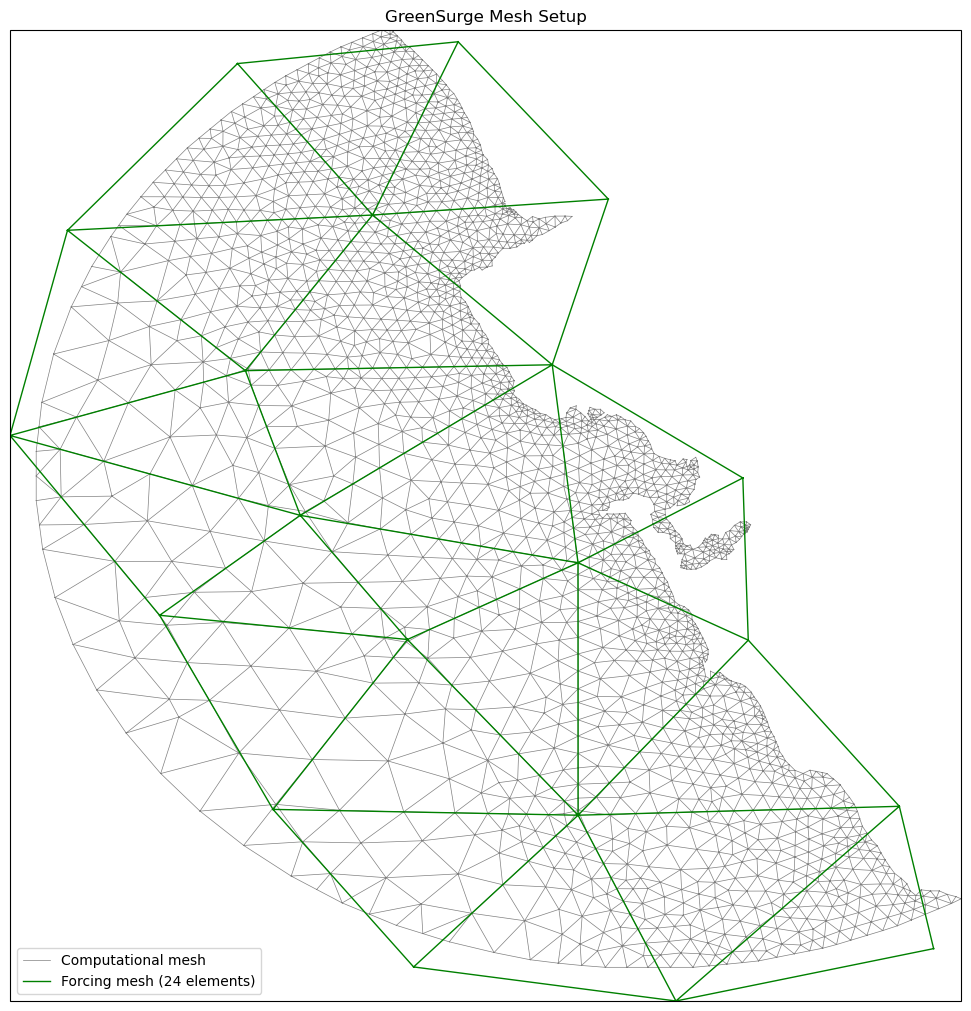

In [19]:
# Build GreenSurge dataset
from bluemath_tk.additive.greensurge import build_greensurge_infos_dataset_pymesh2d

simulation_dataset = build_greensurge_infos_dataset_pymesh2d(
    Nodes_calc=vert_c_geo,
    Elmts_calc=tria_c,
    Nodes_forz=vert_geo,
    Elmts_forz=tria,
    site=site,
    wind_speed=wind_speed,
    direction_step=direction_step,
    simulation_duration_hours=simulation_duration_hours,
    simulation_time_step_hours=simulation_time_step_hours,
    forcing_time_step=forcing_time_step,
    reference_date_dt=reference_date_dt,
    Eddy=Eddy,
    Chezy=Chezy,
)

# Visualize setup
from bluemath_tk.additive.greensurge import plot_greensurge_setup

plot_greensurge_setup(info_ds=simulation_dataset);

In [20]:
import os

# Export to NetCDF
output_file = f"outputs/GreenSurge_{site}_info.nc"
os.makedirs("outputs", exist_ok=True)
simulation_dataset.to_netcdf(output_file, "w", "NETCDF3_CLASSIC")

simulation_dataset

<xarray.Dataset> Size: 174kB
Dimensions:                            (element_computation_index: 3784,
                                        triangle_forcing_nodes: 3,
                                        node_forcing_index: 20,
                                        element_forcing_index: 24,
                                        wind_direction_index: 24,
                                        time_forcing_index: 4,
                                        node_cumputation_index: 2117)
Coordinates:
  * element_computation_index          (element_computation_index) int64 30kB ...
  * node_forcing_index                 (node_forcing_index) int64 160B 0 ... 19
  * element_forcing_index              (element_forcing_index) int64 192B 0 ....
  * wind_direction_index               (wind_direction_index) int64 192B 0 .....
  * time_forcing_index                 (time_forcing_index) float64 32B 0.0 ....
  * node_cumputation_index             (node_cumputation_index) int64 17kB 0 ...
    node_computation_longitude         (node_cumputation_index) float64 17kB ...
    node_computation_latitude          (node_cumputation_index) float64 17kB ...
    triangle_nodes                     (triangle_forcing_nodes) int64 24B 0 1 2
Dimensions without coordinates: triangle_forcing_nodes
Data variables: (12/14)
    triangle_computation_connectivity  (element_computation_index, triangle_forcing_nodes) int64 91kB ...
    node_forcing_longitude             (node_forcing_index) float64 160B -6.8...
    node_forcing_latitude              (node_forcing_index) float64 160B 36.6...
    triangle_forcing_connectivity      (element_forcing_index, triangle_forcing_nodes) int64 576B ...
    wind_directions                    (wind_direction_index) int64 192B 0 .....
    total_elements                     int64 8B 24
    ...                                 ...
    wind_speed                         int64 8B 5
    location_name                      <U5 20B 'Cadiz'
    eddy_viscosity                     int64 8B 10
    chezy_coefficient                  int64 8B 70
    reference_date                     <U19 76B '2022-01-01 00:00:00'
    forcing_time_step                  int64 8B 1
Attributes:
    title:        GreenSurge Simulation Input Dataset
    institution:  GeoOcean
    model:        GreenSurge
    created:      2026-02-18 11:46:24

---

## 9. Grid Export for Delft3D FM

Export the computational mesh in formats compatible with **Delft3D FM**:
- NetCDF format (ADCIRC-style 2DM)
- GRD format with boundary classification

In [21]:
from pymesh2d.geomesh_util.interpolation_mesh import interpolate_from_xr

# Interpolate bathymetry onto mesh vertices
z = interpolate_from_xr(emodnet_sel, vert_c_geo, var_name="elevation")

In [22]:
from pymesh2d.geomesh_util.grd_util import adcirc2DFlowFM

# Export to NetCDF format
adcirc2DFlowFM(np.column_stack((vert_c_geo, z)), tria_c, "templates/mesh_Cadiz_net.nc")

In [23]:
import pickle

with open("outputs/mesh_Cadiz_net.pkl", "wb") as f:
    pickle.dump((vert_c_geo, tria_c, z), f)

In [24]:
from pymesh2d.geomesh_util.border_util import identify_boundary

# Identify boundary types (open ocean vs land)
Boundary = identify_boundary(vert_c_geo, tria_c, z, zlim=5)

In [25]:
from pymesh2d.geomesh_util.grd_util import export_to_grd

# Export to GRD format with boundaries
export_to_grd(
    "outputs/emodnet_grid.grd",
    vert=vert_c_geo,
    tria=tria_c,
    z=z,
    crs=crs,
    edge_tag=Boundary["edge_tag"],
    edge_open=Boundary["edge_open"],
    edge_land=Boundary["edge_land"],
)

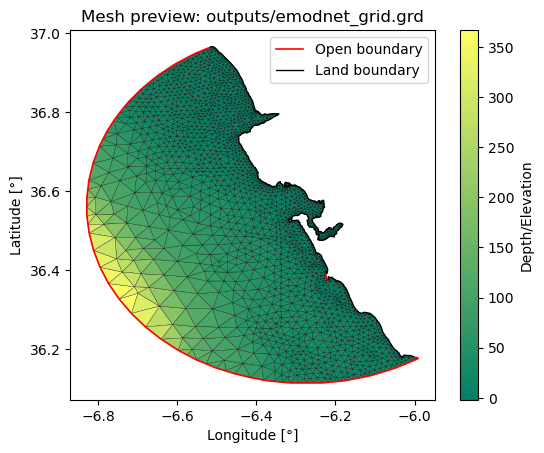

In [26]:
from pymesh2d.geomesh_util.grd_util import plot_grd

# Visualize final grid with boundary classification
plot_grd("outputs/emodnet_grid.grd", show_boundaries=True)

---

## 10. Boundary Conditions Setup

Generate boundary condition files for Delft3D FM:
- `.pli` file: Polyline defining boundary locations
- `.bc` file: Boundary condition time series (Riemann invariants)
- `.ext` file: External forcing configuration

In [27]:
# Select longest open contour (ocean boundary) for forcing application

open_contours = Boundary["open_contours"]
longest_contour_idx = max(
    range(len(open_contours)), key=lambda i: len(open_contours[i])
)
edge_open_closed = open_contours[longest_contour_idx]

Xb = vert_c_geo[edge_open_closed, 0]
Yb = vert_c_geo[edge_open_closed, 1]

In [28]:
# Boundary file parameters
pli = "Boundary01"
bc = "Riemann"
ext = "FlowFM_bnd"
output_path = "templates"

# Write .pli and .bc files
with (
    open(f"{output_path}/{pli}.pli", "w") as file_pli,
    open(f"{output_path}/{bc}.bc", "w") as file_bc,
):
    file_pli.write(f"{pli}\n")
    N = len(Xb)
    file_pli.write(f"    {N}    2\n")

    for i, (xi, yi) in enumerate(zip(Xb, Yb)):
        boundary_id = f"{pli}_{i:04d}"
        file_pli.write(f"{xi:.15E}  {yi:.15E} {boundary_id}\n")

        file_bc.write("[forcing]\n")
        file_bc.write(f"Name = {boundary_id}\n")
        file_bc.write("Function = timeseries\n")
        file_bc.write("Time-interpolation = linear\n")
        file_bc.write("Quantity = time\n")
        file_bc.write("Unit = seconds since 2000-01-01 00:00:00\n")
        file_bc.write("Quantity = riemannbnd\n")
        file_bc.write("Unit = m\n")
        file_bc.write("0    0\n")
        file_bc.write("9999999999   0\n\n")

# Write .ext file
with open(f"{output_path}/{ext}.ext", "w") as file:
    file.write("[general]\n")
    file.write("fileVersion=2.01\n")
    file.write("fileType=extForce\n\n")
    file.write("[boundary]\n")
    file.write("quantity=riemannbnd\n")
    file.write(f"locationFile={pli}.pli\n")
    file.write(f"forcingFile={bc}.bc\n")

---

### References

- **pymesh2D Repository**: [https://github.com/GeoOcean/pymesh2d](https://github.com/GeoOcean/pymesh2d)
- **GreenSurge**: Hybrid storm surge model - GeoOcean Research Group - [https://doi.org/10.1016/j.coastaleng.2024.104691](https://doi.org/10.1016/j.coastaleng.2024.104691)
- **Delft3D FM**: [https://www.deltares.nl/en/software/delft3d-flexible-mesh-suite](https://www.deltares.nl/en/software/delft3d-flexible-mesh-suite)